<a href="https://colab.research.google.com/github/pandreapadilla099-dev/analisis-energias-renovables-latam./blob/main/Copy_of_Proyecto__Producci%C3%B3n_Mensual_de_Energ%C3%ADas_2010_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Los datos incluyen información sobre la producción de energía en varios países mensualmente desde 2010 hasta 2022. La producción de energía se mide en gigavatios-hora (GWh) y cubre una gama de productos energéticos que incluyen hidroeléctrica, eólica, solar, geotérmica, nuclear, combustibles fósiles y otros.

META DATA


Las columnas del conjunto de datos incluyen:

PAÍS: Nombre del país

CODE_TIME: Un código que representa el mes y el año (por ejemplo, JAN2010 para enero de 2010)

HORA: El mes y el año en un formato más legible para humanos (por ejemplo, enero de 2010)

AÑO: El año del punto de datos

MES: El mes del punto de datos como un número (1-12)

MONTH_NAME: El mes del punto de datos como una cadena (por ejemplo, enero)

PRODUCTO: El tipo de producto energético (por ejemplo, hidroeléctrico, eólico, solar)

VALOR: La cantidad de electricidad generada en gigavatios-hora (GWh)

DISPLAY_ORDER: El orden en el que se deben mostrar los productos

yearToDate: La cantidad de electricidad generada durante el año actual hasta el mes actual en GWh

previousYearToDate: La cantidad de electricidad generada durante el año anterior hasta el mes actual en GWh

participación: La participación del producto en la generación total de electricidad del país en formato decimal

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
ruta = '/content/drive/MyDrive/TalentoTech EAM /data.csv'

In [ ]:
df = pd.read_csv(ruta)
#Muestra las primeras 5 filas de la base de datos
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TalentoTech EAM /data.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.columns

Index(['COUNTRY', 'CODE_TIME', 'TIME', 'YEAR', 'MONTH', 'MONTH_NAME',
       'PRODUCT', 'VALUE', 'DISPLAY_ORDER', 'yearToDate', 'previousYearToDate',
       'share'],
      dtype='object')

In [ ]:
df['PRODUCT'].unique()

array(['Hydro', 'Wind', 'Solar', 'Geothermal', 'Total combustible fuels',
       'Coal', 'Oil', 'Natural gas', 'Combustible renewables',
       'Net electricity production', 'Electricity supplied',
       'Used for pumped storage', 'Distribution losses',
       'Final consumption', 'Renewables', 'Non-renewables', 'Others',
       'Other renewables aggregated', 'Low carbon', 'Fossil fuels',
       'Other combustible non-renewables', 'Not specified',
       'Total imports', 'Total exports', 'Electricity trade', 'Nuclear',
       'Other renewables'], dtype=object)

In [ ]:
df['COUNTRY'].unique()

array(['Australia', 'Austria', 'Belgium', 'Canada', 'Chile',
       'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France',
       'Germany', 'Greece', 'Hungary', 'IEA Total', 'Iceland', 'Ireland',
       'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg',
       'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'OECD Americas',
       'OECD Asia Oceania', 'OECD Europe', 'OECD Total', 'Poland',
       'Portugal', 'Republic of Turkiye', 'Slovak Republic', 'Slovenia',
       'Spain', 'Sweden', 'Switzerland', 'United Kingdom',
       'United States', 'Colombia', 'Argentina', 'Brazil', 'Bulgaria',
       'Croatia', 'Cyprus', 'India', 'Malta', 'North Macedonia',
       'Romania', 'Serbia', 'Costa Rica'], dtype=object)

In [ ]:
df.shape
#Filas, Columnas

(181915, 12)

In [ ]:
df.index

RangeIndex(start=0, stop=181915, step=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181915 entries, 0 to 181914
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   COUNTRY             181915 non-null  object 
 1   CODE_TIME           181915 non-null  object 
 2   TIME                181915 non-null  object 
 3   YEAR                181915 non-null  int64  
 4   MONTH               181915 non-null  int64  
 5   MONTH_NAME          181915 non-null  object 
 6   PRODUCT             181915 non-null  object 
 7   VALUE               181915 non-null  float64
 8   DISPLAY_ORDER       181915 non-null  int64  
 9   yearToDate          181915 non-null  float64
 10  previousYearToDate  164810 non-null  float64
 11  share               181915 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 16.7+ MB


In [ ]:
df.describe()

,YEAR,MONTH,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share
count,181915.000000,181915.000000,1.819150e+05,181915.000000,1.819150e+05,1.648100e+05,181915.000000
mean,2016.456818,6.498145,2.091292e+04,14.418410,2.509544e+05,1.382083e+05,0.289057
std,3.657532,3.452288,8.584724e+04,7.819235,1.026864e+06,6.383465e+05,0.427347
min,2010.000000,1.000000,-6.852344e+03,1.000000,-6.667000e+04,-6.667000e+04,-4.649269
25%,2013.000000,3.000000,6.685189e+01,8.000000,8.831870e+02,3.988967e+02,0.009907
50%,2017.000000,6.000000,7.663990e+02,15.000000,9.558855e+03,4.356565e+03,0.082530
75%,2020.000000,9.000000,4.989495e+03,21.000000,5.927517e+04,3.025087e+04,0.511302
max,2022.000000,12.000000,1.001529e+06,27.000000,1.082156e+07,1.082156e+07,5.649269


In [ ]:
!pip install pycountry_convert==0.7.2

In [ ]:
import pycountry_convert as pc

In [ ]:
def country_to_continent(country_name):
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        country_continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
        return country_continent_name
    except:
        return "Unknown"

In [ ]:
df['Continent'] = df['COUNTRY'].apply(lambda x: country_to_continent(x))

In [ ]:
country_counts = df['COUNTRY'].value_counts()
print(country_counts)

COUNTRY
IEA Total              4212
OECD Total             4212
OECD Europe            4212
France                 4200
OECD Americas          4188
OECD Asia Oceania      4140
United Kingdom         4140
United States          4104
Germany                4102
Republic of Turkiye    4094
Canada                 4080
Portugal               4034
Italy                  3996
Belgium                3996
Austria                3996
Czech Republic         3996
Slovak Republic        3985
Spain                  3984
Poland                 3960
Mexico                 3959
Netherlands            3954
New Zealand            3926
Slovenia               3909
Finland                3888
Sweden                 3887
Switzerland            3876
Norway                 3866
Hungary                3858
Luxembourg             3799
Greece                 3791
Japan                  3757
Ireland                3756
Korea                  3744
Lithuania              3731
Denmark                3672
Latvia      

In [ ]:
continent_countries = df.groupby('Continent')['COUNTRY'].unique()
print(continent_countries)

Continent
Asia                                        [Japan, Cyprus, India]
Europe           [Austria, Belgium, Czech Republic, Denmark, Es...
North America          [Canada, Mexico, United States, Costa Rica]
Oceania                                   [Australia, New Zealand]
South America                 [Chile, Colombia, Argentina, Brazil]
Unknown          [IEA Total, Korea, OECD Americas, OECD Asia Oc...
Name: COUNTRY, dtype: object


In [ ]:
sudamerica_df = df[df['Continent'] == 'South America']
sudamerica_df

,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Continent
96,Chile,JAN2010,January 2010,2010,1,January,Hydro,2277.808000,1,21641.001000,NaN,0.476488,South America
97,Chile,JAN2010,January 2010,2010,1,January,Wind,21.126000,2,332.001000,NaN,0.004419,South America
98,Chile,JAN2010,January 2010,2010,1,January,Total combustible fuels,2472.143000,7,36249.001000,NaN,0.517140,South America
99,Chile,JAN2010,January 2010,2010,1,January,Coal,1287.305000,8,15974.071000,NaN,0.269288,South America
100,Chile,JAN2010,January 2010,2010,1,January,Oil,382.032000,9,8022.080000,NaN,0.079916,South America
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180949,Colombia,DEC2022,December 2022,2022,12,December,Non-renewables,1538.170701,23,19520.445158,20404.920447,0.226603,South America
180950,Colombia,DEC2022,December 2022,2022,12,December,Others,224.526296,24,2736.625294,2540.518687,0.033077,South America
180951,Colombia,DEC2022,December 2022,2022,12,December,Other renewables aggregated,181.499851,25,2178.014545,2082.235059,0.026738,South America
180952,Colombia,DEC2022,December 2022,2022,12,December,Low carbon,5249.797902,26,65484.517485,60649.185588,0.773397,South America


In [ ]:
energias_renovables = ['Hydro', 'Wind', 'Geothermal', 'Solar']
df_renovables = df[df['PRODUCT'].isin(energias_renovables)]
df_renovables

,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Continent
0,Australia,JAN2010,January 2010,2010,1,January,Hydro,990.728000,1,16471.891000,NaN,0.047771,Oceania
1,Australia,JAN2010,January 2010,2010,1,January,Wind,409.469000,2,4940.909000,NaN,0.019744,Oceania
2,Australia,JAN2010,January 2010,2010,1,January,Solar,49.216000,3,908.238000,NaN,0.002373,Oceania
3,Australia,JAN2010,January 2010,2010,1,January,Geothermal,0.083000,4,0.996000,NaN,0.000004,Oceania
20,Austria,JAN2010,January 2010,2010,1,January,Hydro,2579.264000,1,39502.566000,NaN,0.437055,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181866,United Kingdom,DEC2022,December 2022,2022,12,December,Solar,508.798542,3,14240.791059,12550.630235,0.018057,Europe
181889,United States,DEC2022,December 2022,2022,12,December,Hydro,22536.684780,1,279561.981565,285825.934087,0.060975,North America
181890,United States,DEC2022,December 2022,2022,12,December,Wind,39343.876029,2,436956.417066,376541.896308,0.106449,North America
181891,United States,DEC2022,December 2022,2022,12,December,Solar,9172.684879,3,188300.466584,152294.007362,0.024818,North America


In [ ]:
df_renovables_sudamerica = df_renovables[df_renovables['Continent'] == 'South America']
df_renovables_sudamerica.to_csv('energias_renovables_sudamerica.csv', index=False)

In [ ]:
energia_por_año_tipo_pais = df_renovables_sudamerica.groupby(['YEAR', 'PRODUCT', 'COUNTRY'])[['VALUE', 'share']].sum().reset_index()
energia_por_año_tipo_pais

,YEAR,PRODUCT,COUNTRY,VALUE,share
0,2010,Hydro,Chile,21641.001000,4.463861
1,2010,Wind,Chile,332.001000,0.068021
2,2011,Hydro,Chile,20937.001000,3.969228
3,2011,Wind,Chile,338.001000,0.064295
4,2012,Hydro,Chile,19976.999000,3.644302
...,...,...,...,...,...
130,2022,Solar,Colombia,474.417453,0.066865
131,2022,Wind,Argentina,14025.337741,1.215134
132,2022,Wind,Brazil,80698.565108,1.512365
133,2022,Wind,Chile,9362.415979,1.336144


In [ ]:
energia_por_año_tipo_pais.columns

Index(['YEAR', 'PRODUCT', 'COUNTRY', 'VALUE', 'share'], dtype='object')

In [ ]:
poblacion_sur_america = '/content/drive/MyDrive/TalentoTech EAM /Poblacion sur america.csv'
dfp = pd.read_csv(poblacion_sur_america)
dfp

,PAÍS,SEXO,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Argentina,Ambos sexos,"41288,7","41730,7","42161,7","42582,5","43024,1",43477,"43900,3","44288,9","44654,9","44973,5",45192,"45312,3","45407,9"
1,Brasil,Ambos sexos,"193701,9","195284,7","196876,1","198478,3","200085,1","201675,5","203218,1","204703,4","206107,3","207455,5","208660,8","209550,3","210306,4"
2,Chile,Ambos sexos,"17181,5","17351,8","17519,1",17687,"17864,2","18047,6","18267,2","18558,9","18893,2","19197,7","19370,6","19456,3",19553
3,Colombia,Ambos sexos,"44777,3","45259,6","45715,8","46151,6","46565,4","46969,9","47437,5","48131,1","49024,5",49908,50630,"51188,2","51737,9"


In [ ]:
dfp_melted = pd.melt(dfp, id_vars=['PAÍS'], value_vars=['2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022'],
                    var_name='YEAR', value_name='Poblacion')

#Mostrar el DataFrame con melt()
print("n/DataFrame despues de aplicar melt():")
print(dfp_melted)

n/DataFrame despues de aplicar melt():
         PAÍS  YEAR Poblacion
0   Argentina  2010   41288,7
1      Brasil  2010  193701,9
2       Chile  2010   17181,5
3    Colombia  2010   44777,3
4   Argentina  2011   41730,7
5      Brasil  2011  195284,7
6       Chile  2011   17351,8
7    Colombia  2011   45259,6
8   Argentina  2012   42161,7
9      Brasil  2012  196876,1
10      Chile  2012   17519,1
11   Colombia  2012   45715,8
12  Argentina  2013   42582,5
13     Brasil  2013  198478,3
14      Chile  2013     17687
15   Colombia  2013   46151,6
16  Argentina  2014   43024,1
17     Brasil  2014  200085,1
18      Chile  2014   17864,2
19   Colombia  2014   46565,4
20  Argentina  2015     43477
21     Brasil  2015  201675,5
22      Chile  2015   18047,6
23   Colombia  2015   46969,9
24  Argentina  2016   43900,3
25     Brasil  2016  203218,1
26      Chile  2016   18267,2
27   Colombia  2016   47437,5
28  Argentina  2017   44288,9
29     Brasil  2017  204703,4
30      Chile  2017   18558,9
3

In [ ]:
nuevo_nombre_columnas = {'A': 'COUNTRY', 'B': 'YEAR', 'C': 'POBLATION'}

# Renombra las columnas
dfP = dfp_melted.rename(columns=nuevo_nombre_columnas)

In [ ]:
# Verifica los nombres de columna
print(dfp_melted.columns)

# Salida: Index(['PAÍS', 'variable', 'value'], dtype='object')

# Ajusta el diccionario
nuevo_nombre_columnas = {'PAÍS': 'COUNTRY', 'YEAR': 'YEAR', 'Poblacion': 'POBLATION'}

# Renombra las columnas
dfP = dfp_melted.rename(columns=nuevo_nombre_columnas)

Index(['PAÍS', 'YEAR', 'Poblacion'], dtype='object')


In [ ]:
dfP

,COUNTRY,YEAR,POBLATION
0,Argentina,2010,"41288,7"
1,Brasil,2010,"193701,9"
2,Chile,2010,"17181,5"
3,Colombia,2010,"44777,3"
4,Argentina,2011,"41730,7"
5,Brasil,2011,"195284,7"
6,Chile,2011,"17351,8"
7,Colombia,2011,"45259,6"
8,Argentina,2012,"42161,7"
9,Brasil,2012,"196876,1"


In [ ]:
sumatoria_energia_año=energia_por_año_tipo_pais.groupby(['YEAR','COUNTRY'])['VALUE'].sum().reset_index().sort_values(by=['YEAR','COUNTRY'], ascending=[True,True])
sumatoria_energia_año

NameError: name 'energia_por_año_tipo_pais' is not defined

In [ ]:
# Convierte la columna 'YEAR' en dfP a tipo int64
dfP['sumatoria_energia_año'] = dfP['YEAR'].astype(int)

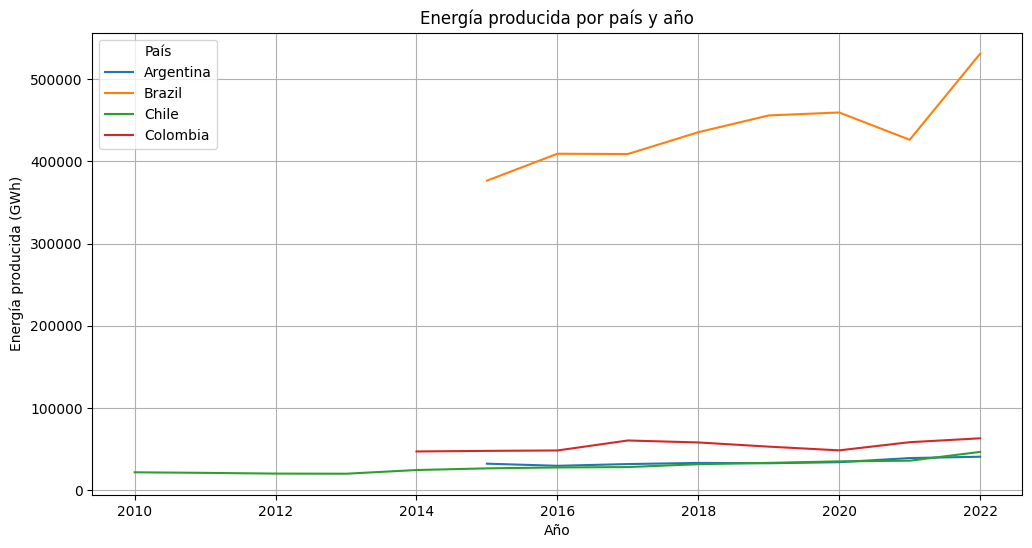

In [ ]:
energia_por_pais_año = sumatoria_energia_año.groupby(['COUNTRY', 'YEAR'])['VALUE'].sum().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.lineplot(x='YEAR', y='VALUE', hue='COUNTRY', data=energia_por_pais_año)
plt.title('Energía producida por país y año')
plt.xlabel('Año')
plt.ylabel('Energía producida (GWh)')
plt.grid(True)
plt.legend(title='País')
plt.show()

In [ ]:
df_combinado = pd.merge(sumatoria_energia_año, dfP, on=['COUNTRY', 'YEAR'], how='outer')
df_combinado

ValueError: You are trying to merge on int64 and object columns for key 'YEAR'. If you wish to proceed you should use pd.concat